In [2]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize Google Earth Engine
try:
    ee.Initialize(project="alien-cedar-483108-h3")
except Exception:
    ee.Authenticate()
    ee.Initialize(project="alien-cedar-483108-h3")

print("Environment ready.")

Environment ready.


In [3]:
# Station information for ML dataset

station_info = {
    "Aurangpur": {
        "lat": 20.821111,
        "lon": 77.540833,
        "year": 2023
    },
    "Bhatsanagar_1": {
        "lat": 19.519534,
        "lon": 73.409324,
        "year": 2024
    },
    "Natuwadi Dam_1": {
        "lat": 17.332778,
        "lon": 73.400000,
        "year": 2024
    }
}

station_info

{'Aurangpur': {'lat': 20.821111, 'lon': 77.540833, 'year': 2023},
 'Bhatsanagar_1': {'lat': 19.519534, 'lon': 73.409324, 'year': 2024},
 'Natuwadi Dam_1': {'lat': 17.332778, 'lon': 73.4, 'year': 2024}}

In [4]:
# ERA5 hourly dataset

era5 = ee.ImageCollection("ECMWF/ERA5/HOURLY")

era5_bands = [
    "temperature_2m",
    "dewpoint_temperature_2m",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
    "surface_pressure",
    "total_precipitation",
    "surface_solar_radiation_downwards",
    "geopotential"
]

print("ERA5 dataset ready.")
print("Variables:", len(era5_bands))

ERA5 dataset ready.
Variables: 8


In [5]:
# Test ERA5 extraction for one station and one day

station = "Aurangpur"
info = station_info[station]

point = ee.Geometry.Point([info["lon"], info["lat"]])

start = ee.Date("2023-01-01")
end = ee.Date("2023-01-02")

test_collection = (
    era5
    .filterDate(start, end)
    .select(era5_bands)
)

def extract_image(image):
    values = image.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=point,
        scale=30000,
        bestEffort=True
    )

    return ee.Feature(
        None,
        values
    ).set(
        "time",
        image.date().format("YYYY-MM-dd HH:mm:ss")
    )

test_features = test_collection.map(extract_image)

test_data = test_features.getInfo()["features"]

print("Number of hourly records:", len(test_data))

# Display first record
test_data[0]["properties"]

Number of hourly records: 24


{'dewpoint_temperature_2m': 285.909912109375,
 'geopotential': 3118.466796875,
 'surface_pressure': 97989.8828125,
 'surface_solar_radiation_downwards': 0,
 'temperature_2m': 290.0060729980469,
 'time': '2023-01-01 00:00:00',
 'total_precipitation': 9.313225746154785e-10,
 'u_component_of_wind_10m': -1.3721048831939697,
 'v_component_of_wind_10m': -1.2799162864685059}

In [6]:
# ============================================================
# Full-year ERA5 feature extraction
# Extracted month-by-month to avoid Earth Engine memory limits
# ============================================================

def extract_station_month(station_name, info, year, month):

    point = ee.Geometry.Point([
        info["lon"],
        info["lat"]
    ])

    start = ee.Date.fromYMD(year, month, 1)

    # First day of next month
    end = start.advance(1, "month")

    collection = (
        era5
        .filterDate(start, end)
        .select(era5_bands)
    )

    def extract_image(image):

        values = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=30000,
            bestEffort=True
        )

        return ee.Feature(
            None,
            values
        ).set(
            "Station", station_name
        ).set(
            "time",
            image.date().format("YYYY-MM-dd HH:mm:ss")
        )

    features = collection.map(extract_image)

    data = features.getInfo()["features"]

    records = []

    for feature in data:

        props = feature["properties"]

        records.append({
            "Station": station_name,
            "time": props.get("time"),

            "temperature_K":
                props.get("temperature_2m"),

            "dewpoint_K":
                props.get("dewpoint_temperature_2m"),

            "u_wind_ms":
                props.get("u_component_of_wind_10m"),

            "v_wind_ms":
                props.get("v_component_of_wind_10m"),

            "surface_pressure_Pa":
                props.get("surface_pressure"),

            "precipitation_m":
                props.get("total_precipitation"),

            "solar_radiation_J_m2":
                props.get(
                    "surface_solar_radiation_downwards"
                ),

            "geopotential":
                props.get("geopotential")
        })

    return pd.DataFrame(records)


# ------------------------------------------------------------
# Extract all station-years month by month
# ------------------------------------------------------------

all_station_features = []

for station, info in station_info.items():

    year = info["year"]

    print(f"\n========== {station} ({year}) ==========")

    for month in range(1, 13):

        print(
            f"Extracting month {month:02d}...",
            end=" "
        )

        df_month = extract_station_month(
            station,
            info,
            year,
            month
        )

        print(f"{len(df_month)} records")

        all_station_features.append(df_month)


# ------------------------------------------------------------
# Combine everything
# ------------------------------------------------------------

era5_ml_features = pd.concat(
    all_station_features,
    ignore_index=True
)


# ------------------------------------------------------------
# Convert timestamps
# ------------------------------------------------------------

era5_ml_features["time_utc"] = pd.to_datetime(
    era5_ml_features["time"],
    utc=True
).dt.floor("h")


# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

era5_ml_features = (
    era5_ml_features
    .sort_values(
        ["Station", "time_utc"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

print("\n========================================")
print("ERA5 extraction complete")
print("========================================")

print(
    "Total records:",
    len(era5_ml_features)
)

print("\nRecords per station:")

print(
    era5_ml_features
    .groupby("Station")
    .size()
)

print("\nMissing values:")

print(
    era5_ml_features
    .isna()
    .sum()
)

display(
    era5_ml_features.head()
)


========== Aurangpur (2023) ==========
Extracting month 01... 744 records
Extracting month 02... 672 records
Extracting month 03... 744 records
Extracting month 04... 720 records
Extracting month 05... 744 records
Extracting month 06... 720 records
Extracting month 07... 744 records
Extracting month 08... 744 records
Extracting month 09... 720 records
Extracting month 10... 744 records
Extracting month 11... 720 records
Extracting month 12... 744 records

========== Bhatsanagar_1 (2024) ==========
Extracting month 01... 744 records
Extracting month 02... 696 records
Extracting month 03... 744 records
Extracting month 04... 720 records
Extracting month 05... 744 records
Extracting month 06... 720 records
Extracting month 07... 744 records
Extracting month 08... 744 records
Extracting month 09... 720 records
Extracting month 10... 744 records
Extracting month 11... 720 records
Extracting month 12... 744 records

========== Natuwadi Dam_1 (2024) ==========
Extracting month 01... 744 reco

,Station,time,temperature_K,dewpoint_K,u_wind_ms,v_wind_ms,surface_pressure_Pa,precipitation_m,solar_radiation_J_m2,geopotential,time_utc
0,Aurangpur,2023-01-01 00:00:00,290.006073,285.909912,-1.372105,-1.279916,97989.882812,9.313226e-10,0.000,3118.466797,2023-01-01 00:00:00+00:00
1,Aurangpur,2023-01-01 01:00:00,290.036438,285.934875,-1.276637,-1.268968,98049.609375,0.000000e+00,0.125,3118.466797,2023-01-01 01:00:00+00:00
2,Aurangpur,2023-01-01 02:00:00,290.888245,285.980103,-1.300927,-1.361869,98138.859375,0.000000e+00,54508.875,3118.466797,2023-01-01 02:00:00+00:00
3,Aurangpur,2023-01-01 03:00:00,292.307129,286.680603,-1.419169,-1.235674,98245.492188,0.000000e+00,586730.250,3118.466797,2023-01-01 03:00:00+00:00
4,Aurangpur,2023-01-01 04:00:00,293.136597,287.043365,-1.557197,-0.953539,98291.234375,9.313226e-10,1319884.125,3118.466797,2023-01-01 04:00:00+00:00


In [7]:
# ============================================================
# Convert ERA5 raw variables into useful ML features
# ============================================================

# Temperature
era5_ml_features["temperature_C"] = (
    era5_ml_features["temperature_K"] - 273.15
)

# Dew point
era5_ml_features["dewpoint_C"] = (
    era5_ml_features["dewpoint_K"] - 273.15
)

# ERA5 elevation
era5_ml_features["era5_elevation_m"] = (
    era5_ml_features["geopotential"] / 9.80665
)

# Wind speed
era5_ml_features["wind_speed_ms"] = np.sqrt(
    era5_ml_features["u_wind_ms"]**2 +
    era5_ml_features["v_wind_ms"]**2
)

# Relative humidity using temperature + dew point
a = 17.625
b = 243.04

es = np.exp(
    (a * era5_ml_features["temperature_C"]) /
    (b + era5_ml_features["temperature_C"])
)

e = np.exp(
    (a * era5_ml_features["dewpoint_C"]) /
    (b + era5_ml_features["dewpoint_C"])
)

era5_ml_features["relative_humidity_pct"] = (
    100 * e / es
)

# Time features
era5_ml_features["hour"] = (
    era5_ml_features["time_utc"].dt.hour
)

era5_ml_features["month"] = (
    era5_ml_features["time_utc"].dt.month
)

era5_ml_features["day_of_year"] = (
    era5_ml_features["time_utc"].dt.dayofyear
)

print("Features created.")

display(
    era5_ml_features[
        [
            "Station",
            "time_utc",
            "temperature_C",
            "dewpoint_C",
            "relative_humidity_pct",
            "wind_speed_ms",
            "surface_pressure_Pa",
            "precipitation_m",
            "solar_radiation_J_m2",
            "era5_elevation_m",
            "hour",
            "month"
        ]
    ].head()
)

Features created.


,Station,time_utc,temperature_C,dewpoint_C,relative_humidity_pct,wind_speed_ms,surface_pressure_Pa,precipitation_m,solar_radiation_J_m2,era5_elevation_m,hour,month
0,Aurangpur,2023-01-01 00:00:00+00:00,16.856073,12.759912,76.802962,1.876395,97989.882812,9.313226e-10,0.000,317.995115,0,1
1,Aurangpur,2023-01-01 01:00:00+00:00,16.886438,12.784875,76.780586,1.800023,98049.609375,0.000000e+00,0.125,317.995115,1,1
2,Aurangpur,2023-01-01 02:00:00+00:00,17.738245,12.830103,72.972400,1.883374,98138.859375,0.000000e+00,54508.875,317.995115,2,1
3,Aurangpur,2023-01-01 03:00:00+00:00,19.157129,13.530603,69.888324,1.881736,98245.492188,0.000000e+00,586730.250,317.995115,3,1
4,Aurangpur,2023-01-01 04:00:00+00:00,19.986597,13.893365,67.962123,1.825952,98291.234375,9.313226e-10,1319884.125,317.995115,4,1


In [8]:
# ============================================================
# Load station observations
# ============================================================

station_path = r"D:\AgroMet\data\raw\maha_temp_raw.csv"


station_df = pd.read_csv(station_path)

print("Shape:", station_df.shape)

print("\nColumns:")
print(station_df.columns.tolist())

display(station_df.head())

Shape: (2831139, 10)

Columns:
['_id', 'SlNo', 'Station', 'Agency', 'State', 'District', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Air Temperature Telemetry Hourly (AoC)']


,_id,SlNo,Station,Agency,State,District,Latitude,Longitude,Data Acquisition Time,Air Temperature Telemetry Hourly (AoC)
0,2823784,2823784,Yeldari dam_1,Maharashtra SW,Maharashtra,Parbhani,19.715278,76.720833,09-03-2025 13:00,37.1
1,2817023,2817023,Yeldari dam_1,Maharashtra SW,Maharashtra,Parbhani,19.715278,76.720833,23-09-2024 20:00,17.7
2,2811870,2811870,Yeldari dam_1,Maharashtra SW,Maharashtra,Parbhani,19.715278,76.720833,13-02-2024 00:00,20.7
3,2823802,2823802,Yeldari dam_1,Maharashtra SW,Maharashtra,Parbhani,19.715278,76.720833,10-03-2025 09:00,17.0
4,2827080,2827080,Yeldari dam_1,Maharashtra SW,Maharashtra,Parbhani,19.715278,76.720833,16-07-2025 05:00,25.5


In [9]:
# ============================================================
# Sanity check ERA5 ML features
# ============================================================

print("Rows per station:")
print(
    era5_ml_features
    .groupby("Station")
    .size()
)

print("\nMissing values:")
print(
    era5_ml_features.isna().sum()
)

print("\nFeature ranges:")
display(
    era5_ml_features[
        [
            "temperature_C",
            "dewpoint_C",
            "u_wind_ms",
            "v_wind_ms",
            "surface_pressure_Pa",
            "precipitation_m",
            "solar_radiation_J_m2",
            "era5_elevation_m"
        ]
    ].describe().T
)

Rows per station:
Station
Aurangpur         8760
Bhatsanagar_1     8784
Natuwadi Dam_1    8784
dtype: int64

Missing values:
Station                   0
time                      0
temperature_K             0
dewpoint_K                0
u_wind_ms                 0
v_wind_ms                 0
surface_pressure_Pa       0
precipitation_m          14
solar_radiation_J_m2     14
geopotential              0
time_utc                  0
temperature_C             0
dewpoint_C                0
era5_elevation_m          0
wind_speed_ms             0
relative_humidity_pct     0
hour                      0
month                     0
day_of_year               0
dtype: int64

Feature ranges:


,count,mean,std,min,25%,50%,75%,max
temperature_C,26328.0,27.058754,4.366723e+00,1.023528e+01,24.975298,26.870157,2.943232e+01,4.330630e+01
dewpoint_C,26328.0,20.253620,4.795656e+00,2.392999e+00,16.638017,21.387323,2.449714e+01,2.804666e+01
u_wind_ms,26328.0,1.182405,2.252427e+00,-5.179657e+00,-0.569795,1.067026,2.814167e+00,1.005159e+01
v_wind_ms,26328.0,-0.403300,1.915500e+00,-6.930061e+00,-1.595227,-0.551452,6.967525e-01,7.905818e+00
surface_pressure_Pa,26328.0,98615.466319,1.244265e+03,7.674559e+04,97665.957031,98416.898438,9.989504e+04,1.010068e+05
precipitation_m,26314.0,0.000244,7.596739e-04,-3.725290e-09,0.000000,0.000000,6.691087e-05,1.522625e-02
solar_radiation_J_m2,26314.0,755617.612944,1.049754e+06,-2.500000e-01,0.000000,29007.375000,1.420213e+06,3.669632e+06
era5_elevation_m,26328.0,202.234000,1.055113e+02,6.784085e+01,67.841401,220.570592,3.179951e+02,2.858814e+03


In [10]:
# ============================================================
# Load and prepare station observations
# ============================================================

station_path = r"D:\AgroMet\data\raw\maha_temp_raw.csv"

station_df = pd.read_csv(station_path)

# Keep only our 3 stations
station_df = station_df[
    station_df["Station"].isin(station_info.keys())
].copy()

# Parse timestamp
station_df["time"] = pd.to_datetime(
    station_df["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# Convert IST -> UTC
station_df["time_utc"] = (
    station_df["time"]
    .dt.tz_localize("Asia/Kolkata")
    .dt.tz_convert("UTC")
    .dt.floor("h")
)

# Rename observed temperature
station_df["observed_temperature_C"] = (
    station_df["Air Temperature Telemetry Hourly (AoC)"]
)

# Keep only relevant columns
station_obs = station_df[
    [
        "Station",
        "time_utc",
        "observed_temperature_C"
    ]
].copy()

# Remove invalid timestamps
station_obs = station_obs.dropna(
    subset=["time_utc"]
)

# Remove duplicate station-hours by averaging
station_obs = (
    station_obs
    .groupby(
        ["Station", "time_utc"],
        as_index=False
    )["observed_temperature_C"]
    .mean()
)

print("Observation records:", len(station_obs))

print("\nRecords per station:")
print(
    station_obs
    .groupby("Station")
    .size()
)

display(station_obs.head())

Observation records: 77286

Records per station:
Station
Aurangpur         29118
Bhatsanagar_1     17946
Natuwadi Dam_1    30222
dtype: int64


,Station,time_utc,observed_temperature_C
0,Aurangpur,2021-06-02 11:00:00+00:00,0.0
1,Aurangpur,2021-06-02 12:00:00+00:00,0.0
2,Aurangpur,2021-06-02 13:00:00+00:00,0.0
3,Aurangpur,2021-06-02 14:00:00+00:00,0.0
4,Aurangpur,2021-06-03 11:00:00+00:00,0.0


In [11]:
# ============================================================
# Filter observations to the exact station-year periods
# ============================================================

station_obs = station_obs.copy()

# Keep only the year assigned to each station
station_obs["expected_year"] = station_obs["Station"].map(
    {
        station: info["year"]
        for station, info in station_info.items()
    }
)

station_obs = station_obs[
    station_obs["time_utc"].dt.year == station_obs["expected_year"]
].copy()

# Remove helper column
station_obs = station_obs.drop(
    columns=["expected_year"]
)

print("Observation records:", len(station_obs))

print("\nRecords per station:")
print(
    station_obs
    .groupby("Station")
    .size()
)

print("\nDate ranges:")
print(
    station_obs
    .groupby("Station")["time_utc"]
    .agg(["min", "max"])
)

Observation records: 25504

Records per station:
Station
Aurangpur         8647
Bhatsanagar_1     8435
Natuwadi Dam_1    8422
dtype: int64

Date ranges:
                                     min                       max
Station                                                           
Aurangpur      2023-01-01 00:00:00+00:00 2023-12-31 23:00:00+00:00
Bhatsanagar_1  2024-01-01 00:00:00+00:00 2024-12-31 23:00:00+00:00
Natuwadi Dam_1 2024-01-01 00:00:00+00:00 2024-12-31 23:00:00+00:00


In [12]:
# ============================================================
# Merge ERA5 features with station observations
# ============================================================

ml_data = era5_ml_features.merge(
    station_obs,
    on=["Station", "time_utc"],
    how="inner"
)

print("Merged records:", len(ml_data))

print("\nRecords per station:")
print(
    ml_data
    .groupby("Station")
    .size()
)

print("\nMissing observations:")
print(
    ml_data["observed_temperature_C"].isna().sum()
)

display(
    ml_data[
        [
            "Station",
            "time_utc",
            "temperature_C",
            "dewpoint_C",
            "relative_humidity_pct",
            "wind_speed_ms",
            "surface_pressure_Pa",
            "precipitation_m",
            "solar_radiation_J_m2",
            "observed_temperature_C"
        ]
    ].head()
)

Merged records: 25504

Records per station:
Station
Aurangpur         8647
Bhatsanagar_1     8435
Natuwadi Dam_1    8422
dtype: int64

Missing observations:
0


,Station,time_utc,temperature_C,dewpoint_C,relative_humidity_pct,wind_speed_ms,surface_pressure_Pa,precipitation_m,solar_radiation_J_m2,observed_temperature_C
0,Aurangpur,2023-01-01 00:00:00+00:00,16.856073,12.759912,76.802962,1.876395,97989.882812,9.313226e-10,0.000,13.2
1,Aurangpur,2023-01-01 01:00:00+00:00,16.886438,12.784875,76.780586,1.800023,98049.609375,0.000000e+00,0.125,12.3
2,Aurangpur,2023-01-01 02:00:00+00:00,17.738245,12.830103,72.972400,1.883374,98138.859375,0.000000e+00,54508.875,14.6
3,Aurangpur,2023-01-01 03:00:00+00:00,19.157129,13.530603,69.888324,1.881736,98245.492188,0.000000e+00,586730.250,19.5
4,Aurangpur,2023-01-01 04:00:00+00:00,19.986597,13.893365,67.962123,1.825952,98291.234375,9.313226e-10,1319884.125,22.2


In [13]:
# ============================================================
# Add SRTM elevation and physics-based prediction
# ============================================================

# SRTM elevation at each station (metres)
srtm_elevation = {
    "Aurangpur": 286,
    "Bhatsanagar_1": 186,
    "Natuwadi Dam_1": 207
}

ml_data["srtm_elevation_m"] = (
    ml_data["Station"]
    .map(srtm_elevation)
)

# Elevation difference:
# local SRTM elevation - ERA5 elevation
ml_data["elevation_difference_m"] = (
    ml_data["srtm_elevation_m"]
    - ml_data["era5_elevation_m"]
)

# Standard atmospheric lapse rate
LAPSE_RATE = 6.5  # °C per km

# Physics-downscaled temperature
ml_data["physics_prediction_C"] = (
    ml_data["temperature_C"]
    - LAPSE_RATE
    * ml_data["elevation_difference_m"]
    / 1000
)

# Residual = what physics failed to explain
ml_data["residual_C"] = (
    ml_data["observed_temperature_C"]
    - ml_data["physics_prediction_C"]
)

print("Physics baseline added.")

display(
    ml_data[
        [
            "Station",
            "time_utc",
            "temperature_C",
            "era5_elevation_m",
            "srtm_elevation_m",
            "elevation_difference_m",
            "physics_prediction_C",
            "observed_temperature_C",
            "residual_C"
        ]
    ].head()
)

Physics baseline added.


,Station,time_utc,temperature_C,era5_elevation_m,srtm_elevation_m,elevation_difference_m,physics_prediction_C,observed_temperature_C,residual_C
0,Aurangpur,2023-01-01 00:00:00+00:00,16.856073,317.995115,286,-31.995115,17.064041,13.2,-3.864041
1,Aurangpur,2023-01-01 01:00:00+00:00,16.886438,317.995115,286,-31.995115,17.094406,12.3,-4.794406
2,Aurangpur,2023-01-01 02:00:00+00:00,17.738245,317.995115,286,-31.995115,17.946213,14.6,-3.346213
3,Aurangpur,2023-01-01 03:00:00+00:00,19.157129,317.995115,286,-31.995115,19.365097,19.5,0.134903
4,Aurangpur,2023-01-01 04:00:00+00:00,19.986597,317.995115,286,-31.995115,20.194565,22.2,2.005435


In [14]:
# ============================================================
# Clean invalid station observations
# ============================================================

# Count suspicious zero values
zero_count = (
    ml_data["observed_temperature_C"] == 0
).sum()

print("0°C observations:", zero_count)

# Replace sensor-coded 0°C values with NaN
ml_data.loc[
    ml_data["observed_temperature_C"] == 0,
    "observed_temperature_C"
] = np.nan

# Remove those rows
ml_data = ml_data.dropna(
    subset=["observed_temperature_C"]
).copy()

# Recalculate residual after cleaning
ml_data["residual_C"] = (
    ml_data["observed_temperature_C"]
    - ml_data["physics_prediction_C"]
)

print("\nClean ML dataset:", len(ml_data), "rows")

print("\nRows per station:")
print(
    ml_data.groupby("Station").size()
)

print("\nResidual statistics:")
display(
    ml_data["residual_C"].describe()
)

0°C observations: 180

Clean ML dataset: 25324 rows

Rows per station:
Station
Aurangpur         8570
Bhatsanagar_1     8434
Natuwadi Dam_1    8320
dtype: int64

Residual statistics:


count    25324.000000
mean        -0.266120
std          2.933934
min        -30.851578
25%         -1.867093
50%         -0.220682
75%          1.524597
max         18.813126
Name: residual_C, dtype: float64

In [15]:
# ============================================================
# Inspect extreme residuals
# ============================================================

extreme_residuals = (
    ml_data[
        ml_data["residual_C"].abs() > 10
    ]
    .sort_values("residual_C")
)

print(
    "Residuals with absolute error > 10°C:",
    len(extreme_residuals)
)

display(
    extreme_residuals[
        [
            "Station",
            "time_utc",
            "temperature_C",
            "physics_prediction_C",
            "observed_temperature_C",
            "residual_C"
        ]
    ].head(30)
)

Residuals with absolute error > 10°C: 98


,Station,time_utc,temperature_C,physics_prediction_C,observed_temperature_C,residual_C
3585,Aurangpur,2023-06-03 02:00:00+00:00,33.643610,33.851578,3.0,-30.851578
8660,Bhatsanagar_1,2024-01-01 13:00:00+00:00,29.174615,29.399324,4.7,-24.699324
8659,Bhatsanagar_1,2024-01-01 12:00:00+00:00,29.458704,29.683412,5.1,-24.583412
8754,Bhatsanagar_1,2024-01-05 12:00:00+00:00,27.697382,27.922090,3.6,-24.322090
8706,Bhatsanagar_1,2024-01-03 12:00:00+00:00,27.994165,28.218874,3.9,-24.318874
8683,Bhatsanagar_1,2024-01-02 13:00:00+00:00,28.579889,28.804598,4.5,-24.304598
8682,Bhatsanagar_1,2024-01-02 12:00:00+00:00,28.540979,28.765688,4.7,-24.065688
8755,Bhatsanagar_1,2024-01-05 13:00:00+00:00,26.916895,27.141603,3.2,-23.941603
8730,Bhatsanagar_1,2024-01-04 12:00:00+00:00,27.724146,27.948854,4.2,-23.748854
8707,Bhatsanagar_1,2024-01-03 13:00:00+00:00,27.440210,27.664919,4.1,-23.564919


In [16]:
# ============================================================
# Summarize extreme residuals by station
# ============================================================

extreme = ml_data[
    ml_data["residual_C"].abs() > 10
].copy()

print("Extreme residuals by station:")
print(
    extreme.groupby("Station").size()
)

print("\nObserved temperature range for extreme residuals:")
print(
    extreme.groupby("Station")["observed_temperature_C"]
    .agg(["count", "min", "max", "mean"])
)

print("\nExtreme residual date ranges:")
print(
    extreme.groupby("Station")["time_utc"]
    .agg(["min", "max"])
)

Extreme residuals by station:
Station
Aurangpur         21
Bhatsanagar_1     55
Natuwadi Dam_1    22
dtype: int64

Observed temperature range for extreme residuals:
                count   min   max       mean
Station                                     
Aurangpur          21   2.0  37.8  26.371429
Bhatsanagar_1      55   3.2  28.7   8.589091
Natuwadi Dam_1     22  28.5  43.0  40.327273

Extreme residual date ranges:
                                     min                       max
Station                                                           
Aurangpur      2023-02-10 22:00:00+00:00 2023-11-24 16:00:00+00:00
Bhatsanagar_1  2024-01-01 04:00:00+00:00 2024-01-20 06:00:00+00:00
Natuwadi Dam_1 2024-01-20 06:00:00+00:00 2024-05-14 09:00:00+00:00


In [17]:
# Show all extreme residual observations in chronological order

extreme_view = ml_data[
    ml_data["residual_C"].abs() > 10
][[
    "Station",
    "time_utc",
    "observed_temperature_C",
    "temperature_C",
    "physics_prediction_C",
    "residual_C"
]].sort_values(["Station", "time_utc"])

pd.set_option("display.max_rows", 120)

display(extreme_view)

,Station,time_utc,observed_temperature_C,temperature_C,physics_prediction_C,residual_C
925,Aurangpur,2023-02-10 22:00:00+00:00,32.3,16.117792,16.325760,15.974240
926,Aurangpur,2023-02-10 23:00:00+00:00,35.0,15.978906,16.186874,18.813126
927,Aurangpur,2023-02-11 00:00:00+00:00,35.0,18.451440,18.659409,16.340591
928,Aurangpur,2023-02-11 01:00:00+00:00,35.4,18.618585,18.826553,16.573447
1519,Aurangpur,2023-03-08 00:00:00+00:00,10.4,20.534204,20.742172,-10.342172
1801,Aurangpur,2023-03-19 18:00:00+00:00,2.0,22.111444,22.319412,-20.319412
1949,Aurangpur,2023-03-25 22:00:00+00:00,35.6,23.004694,23.212662,12.387338
1950,Aurangpur,2023-03-25 23:00:00+00:00,37.0,23.126764,23.334732,13.665268
1965,Aurangpur,2023-03-26 22:00:00+00:00,34.4,21.317316,21.525284,12.874716
1980,Aurangpur,2023-03-27 21:00:00+00:00,33.7,23.024469,23.232437,10.467563


In [18]:
# Count extreme residuals by station and date

extreme = ml_data[ml_data["residual_C"].abs() > 10].copy()

extreme["date"] = extreme["time_utc"].dt.date

daily_extremes = (
    extreme.groupby(["Station", "date"])
    .size()
    .reset_index(name="extreme_count")
    .sort_values(["Station", "date"])
)

display(daily_extremes)

,Station,date,extreme_count
0,Aurangpur,2023-02-10,2
1,Aurangpur,2023-02-11,2
2,Aurangpur,2023-03-08,1
3,Aurangpur,2023-03-19,1
4,Aurangpur,2023-03-25,2
5,Aurangpur,2023-03-26,1
6,Aurangpur,2023-03-27,3
7,Aurangpur,2023-03-28,2
8,Aurangpur,2023-04-07,4
9,Aurangpur,2023-06-03,1


In [19]:
# Check how many observations fall inside the suspicious Bhatsanagar period

bad_period = (
    (ml_data["Station"] == "Bhatsanagar_1") &
    (ml_data["time_utc"] >= "2024-01-01 00:00:00+00:00") &
    (ml_data["time_utc"] <= "2024-01-06 23:59:59+00:00")
)

print("Rows in Bhatsanagar suspicious period:", bad_period.sum())

print("\nResidual statistics in this period:")
print(
    ml_data.loc[bad_period, "residual_C"]
    .describe()
)

print("\nObserved temperature statistics:")
print(
    ml_data.loc[bad_period, "observed_temperature_C"]
    .describe()
)

Rows in Bhatsanagar suspicious period: 141

Residual statistics in this period:
count    141.000000
mean      -7.378523
std        9.877104
min      -24.699324
25%      -18.022481
50%       -1.481417
75%        0.663786
max        3.626280
Name: residual_C, dtype: float64

Observed temperature statistics:
count    141.000000
mean      16.372695
std        7.212285
min        3.200000
25%       10.100000
50%       18.800000
75%       21.600000
max       33.200000
Name: observed_temperature_C, dtype: float64


In [20]:
thresholds = [5, 7.5, 10, 15, 20]

for threshold in thresholds:
    count = (ml_data["residual_C"].abs() > threshold).sum()
    pct = count / len(ml_data) * 100
    
    print(
        f"|residual| > {threshold:>4}°C: "
        f"{count:>4} rows ({pct:.2f}%)"
    )

|residual| >    5°C: 2050 rows (8.10%)
|residual| >  7.5°C:  371 rows (1.47%)
|residual| >   10°C:   98 rows (0.39%)
|residual| >   15°C:   55 rows (0.22%)
|residual| >   20°C:   29 rows (0.11%)


In [21]:
import numpy as np

ml_data["hour_sin"] = np.sin(2 * np.pi * ml_data["hour"] / 24)
ml_data["hour_cos"] = np.cos(2 * np.pi * ml_data["hour"] / 24)

ml_data["doy_sin"] = np.sin(2 * np.pi * ml_data["day_of_year"] / 365.25)
ml_data["doy_cos"] = np.cos(2 * np.pi * ml_data["day_of_year"] / 365.25)

print(
    ml_data[
        ["hour", "hour_sin", "hour_cos",
         "day_of_year", "doy_sin", "doy_cos"]
    ].head()
)

   hour  hour_sin  hour_cos  day_of_year   doy_sin   doy_cos
0     0  0.000000  1.000000            1  0.017202  0.999852
1     1  0.258819  0.965926            1  0.017202  0.999852
2     2  0.500000  0.866025            1  0.017202  0.999852
3     3  0.707107  0.707107            1  0.017202  0.999852
4     4  0.866025  0.500000            1  0.017202  0.999852


In [22]:
extreme_15 = ml_data[
    ml_data["residual_C"].abs() > 15
].copy()

print("Extreme >15°C by station:")
print(extreme_15.groupby("Station").size())

print("\nExtreme >15°C by hour:")
print(
    extreme_15.groupby("hour")
    .size()
    .sort_index()
)

print("\nExtreme >15°C by month:")
print(
    extreme_15.groupby("month")
    .size()
    .sort_index()
)

Extreme >15°C by station:
Station
Aurangpur          8
Bhatsanagar_1     46
Natuwadi Dam_1     1
dtype: int64

Extreme >15°C by hour:
hour
0     1
1     1
2     1
5     4
6     7
7     4
8     5
9     5
10    5
11    5
12    5
13    5
14    2
16    1
18    1
22    1
23    2
dtype: int64

Extreme >15°C by month:
month
1     47
2      4
3      2
6      1
11     1
dtype: int64


In [23]:
# Create quality-controlled dataset for ML training

ml_data_qc = ml_data[
    ml_data["residual_C"].abs() <= 15
].copy()

print("Original rows:", len(ml_data))
print("QC rows:", len(ml_data_qc))
print("Removed rows:", len(ml_data) - len(ml_data_qc))

print("\nRows removed by station:")
print(
    ml_data.loc[
        ml_data["residual_C"].abs() > 15
    ]
    .groupby("Station")
    .size()
)

Original rows: 25324
QC rows: 25269
Removed rows: 55

Rows removed by station:
Station
Aurangpur          8
Bhatsanagar_1     46
Natuwadi Dam_1     1
dtype: int64


In [24]:
feature_columns = [
    "temperature_C",
    "dewpoint_C",
    "wind_speed_ms",
    "surface_pressure_Pa",
    "precipitation_m",
    "solar_radiation_J_m2",
    "era5_elevation_m",
    "srtm_elevation_m",
    "elevation_difference_m",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

X = ml_data_qc[feature_columns].copy()
y = ml_data_qc["residual_C"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nMissing values:")
print(X.isna().sum())

X shape: (25269, 13)
y shape: (25269,)

Features:
['temperature_C', 'dewpoint_C', 'wind_speed_ms', 'surface_pressure_Pa', 'precipitation_m', 'solar_radiation_J_m2', 'era5_elevation_m', 'srtm_elevation_m', 'elevation_difference_m', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']

Missing values:
temperature_C              0
dewpoint_C                 0
wind_speed_ms              0
surface_pressure_Pa        0
precipitation_m           14
solar_radiation_J_m2      14
era5_elevation_m           0
srtm_elevation_m           0
elevation_difference_m     0
hour_sin                   0
hour_cos                   0
doy_sin                    0
doy_cos                    0
dtype: int64


In [25]:
# Remove rows with missing ML features

valid_features = X.notna().all(axis=1)

X_clean = X.loc[valid_features].copy()
y_clean = y.loc[valid_features].copy()

print("Original rows:", len(X))
print("Rows after removing missing features:", len(X_clean))
print("Rows removed:", len(X) - len(X_clean))

Original rows: 25269
Rows after removing missing features: 25255
Rows removed: 14


In [26]:
station_labels = ml_data_qc.loc[
    valid_features, "Station"
].copy()

print("Station counts:")
print(station_labels.value_counts())

Station counts:
Station
Aurangpur         8562
Bhatsanagar_1     8381
Natuwadi Dam_1    8312
Name: count, dtype: int64


In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Keep all required evaluation columns aligned with X_clean
eval_data = ml_data_qc.loc[valid_features, [
    "Station",
    "physics_prediction_C",
    "observed_temperature_C"
]].copy()

eval_data = eval_data.loc[X_clean.index]

results = []

for test_station in station_labels.unique():

    train_mask = station_labels != test_station
    test_mask = station_labels == test_station

    X_train = X_clean.loc[train_mask]
    X_test = X_clean.loc[test_mask]

    y_train = y_clean.loc[train_mask]
    y_test = y_clean.loc[test_mask]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    residual_pred = model.predict(X_test)

    test_eval = eval_data.loc[X_test.index]

    physics_test = test_eval["physics_prediction_C"]
    observed_test = test_eval["observed_temperature_C"]

    final_prediction = physics_test.values + residual_pred

    physics_mae = mean_absolute_error(
        observed_test,
        physics_test
    )

    physics_rmse = np.sqrt(
        mean_squared_error(
            observed_test,
            physics_test
        )
    )

    ml_mae = mean_absolute_error(
        observed_test,
        final_prediction
    )

    ml_rmse = np.sqrt(
        mean_squared_error(
            observed_test,
            final_prediction
        )
    )

    results.append({
        "test_station": test_station,
        "physics_MAE": physics_mae,
        "physics_RMSE": physics_rmse,
        "ML_MAE": ml_mae,
        "ML_RMSE": ml_rmse
    })

results_df = pd.DataFrame(results)

display(results_df)

,test_station,physics_MAE,physics_RMSE,ML_MAE,ML_RMSE
0,Aurangpur,2.299667,2.923592,1.712914,2.292011
1,Bhatsanagar_1,1.730506,2.244315,1.612487,2.162105
2,Natuwadi Dam_1,2.366814,3.125058,1.949088,2.563447


In [28]:
from sklearn.linear_model import Ridge

ridge_results = []

for test_station in station_labels.unique():

    train_mask = station_labels != test_station
    test_mask = station_labels == test_station

    X_train = X_clean.loc[train_mask]
    X_test = X_clean.loc[test_mask]

    y_train = y_clean.loc[train_mask]
    y_test = y_clean.loc[test_mask]

    model = Ridge(alpha=10.0)

    model.fit(X_train, y_train)

    residual_pred = model.predict(X_test)

    test_eval = eval_data.loc[X_test.index]

    physics_test = test_eval["physics_prediction_C"]
    observed_test = test_eval["observed_temperature_C"]

    final_prediction = physics_test.values + residual_pred

    ml_mae = mean_absolute_error(
        observed_test,
        final_prediction
    )

    ml_rmse = np.sqrt(
        mean_squared_error(
            observed_test,
            final_prediction
        )
    )

    ridge_results.append({
        "test_station": test_station,
        "Ridge_MAE": ml_mae,
        "Ridge_RMSE": ml_rmse
    })

ridge_results_df = pd.DataFrame(ridge_results)

display(ridge_results_df)

,test_station,Ridge_MAE,Ridge_RMSE
0,Aurangpur,8.746547,8.973249
1,Bhatsanagar_1,1.722264,2.237435
2,Natuwadi Dam_1,1.922996,2.471436


In [29]:
feature_columns_no_elevation = [
    "temperature_C",
    "dewpoint_C",
    "wind_speed_ms",
    "surface_pressure_Pa",
    "precipitation_m",
    "solar_radiation_J_m2",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

X_no_elevation = ml_data_qc.loc[
    valid_features, feature_columns_no_elevation
].copy()

print("Shape:", X_no_elevation.shape)
print("Missing values:")
print(X_no_elevation.isna().sum())

Shape: (25255, 10)
Missing values:
temperature_C           0
dewpoint_C              0
wind_speed_ms           0
surface_pressure_Pa     0
precipitation_m         0
solar_radiation_J_m2    0
hour_sin                0
hour_cos                0
doy_sin                 0
doy_cos                 0
dtype: int64


In [30]:
rf_no_elevation_results = []

for test_station in station_labels.unique():

    train_mask = station_labels != test_station
    test_mask = station_labels == test_station

    X_train = X_no_elevation.loc[train_mask]
    X_test = X_no_elevation.loc[test_mask]

    y_train = y_clean.loc[train_mask]
    y_test = y_clean.loc[test_mask]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    residual_pred = model.predict(X_test)

    test_eval = eval_data.loc[X_test.index]

    physics_test = test_eval["physics_prediction_C"]
    observed_test = test_eval["observed_temperature_C"]

    final_prediction = physics_test.values + residual_pred

    ml_mae = mean_absolute_error(
        observed_test,
        final_prediction
    )

    ml_rmse = np.sqrt(
        mean_squared_error(
            observed_test,
            final_prediction
        )
    )

    rf_no_elevation_results.append({
        "test_station": test_station,
        "RF_no_elevation_MAE": ml_mae,
        "RF_no_elevation_RMSE": ml_rmse
    })

rf_no_elevation_df = pd.DataFrame(rf_no_elevation_results)

display(rf_no_elevation_df)

,test_station,RF_no_elevation_MAE,RF_no_elevation_RMSE
0,Aurangpur,1.722490,2.309040
1,Bhatsanagar_1,1.629030,2.184356
2,Natuwadi Dam_1,1.767264,2.329530


In [31]:
rf_full = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X_no_elevation, y_clean)

feature_importance = pd.Series(
    rf_full.feature_importances_,
    index=X_no_elevation.columns
).sort_values(ascending=False)

display(feature_importance)

solar_radiation_J_m2    0.433469
surface_pressure_Pa     0.135488
dewpoint_C              0.105954
doy_sin                 0.092558
doy_cos                 0.054111
wind_speed_ms           0.044167
temperature_C           0.042601
hour_cos                0.040374
hour_sin                0.036770
precipitation_m         0.014507
dtype: float64

In [32]:
rf_predictions = {}

for test_station in station_labels.unique():

    train_idx = station_labels != test_station
    test_idx = station_labels == test_station

    X_train = X_no_elevation.loc[train_idx]
    y_train = y_clean.loc[train_idx]

    X_test = X_no_elevation.loc[test_idx]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    rf_predictions[test_station] = rf.predict(X_test)

In [33]:
rf_pred = rf_predictions[station]
rf_pred

array([-1.07003363, -1.10425552, -1.05936201, ..., -1.86995202,
       -1.60209782, -1.42987439], shape=(8312,))

In [34]:
results = []

for station in station_labels.unique():

    test_idx = station_labels == station

    physics = eval_data.loc[test_idx, "physics_prediction_C"]
    observed = eval_data.loc[test_idx, "observed_temperature_C"]

    # RF predicts RESIDUAL, not temperature
    predicted_residual = rf_predictions[station]

    # Convert residual prediction into final temperature
    rf_pred = physics.to_numpy() + predicted_residual

    physics_mae = mean_absolute_error(observed, physics)
    rf_mae = mean_absolute_error(observed, rf_pred)

    physics_rmse = mean_squared_error(observed, physics) ** 0.5
    rf_rmse = mean_squared_error(observed, rf_pred) ** 0.5

    results.append({
        "Station": station,
        "Physics_MAE": physics_mae,
        "RF_MAE": rf_mae,
        "MAE_Improvement_%": 100 * (physics_mae - rf_mae) / physics_mae,
        "Physics_RMSE": physics_rmse,
        "RF_RMSE": rf_rmse,
        "RMSE_Improvement_%": 100 * (physics_rmse - rf_rmse) / physics_rmse
    })

results_df = pd.DataFrame(results)

display(results_df)

,Station,Physics_MAE,RF_MAE,MAE_Improvement_%,Physics_RMSE,RF_RMSE,RMSE_Improvement_%
0,Aurangpur,2.299667,1.722490,25.098288,2.923592,2.309040,21.020461
1,Bhatsanagar_1,1.730506,1.629030,5.863983,2.244315,2.184356,2.671587
2,Natuwadi Dam_1,2.366814,1.767264,25.331534,3.125058,2.329530,25.456429


In [35]:
overall_physics_mae = results_df["Physics_MAE"].mean()
overall_rf_mae = results_df["RF_MAE"].mean()

overall_physics_rmse = results_df["Physics_RMSE"].mean()
overall_rf_rmse = results_df["RF_RMSE"].mean()

print(f"Average Physics MAE: {overall_physics_mae:.3f} °C")
print(f"Average RF MAE:      {overall_rf_mae:.3f} °C")
print(f"MAE improvement:     {100 * (overall_physics_mae - overall_rf_mae) / overall_physics_mae:.1f}%")

print()

print(f"Average Physics RMSE: {overall_physics_rmse:.3f} °C")
print(f"Average RF RMSE:      {overall_rf_rmse:.3f} °C")
print(f"RMSE improvement:     {100 * (overall_physics_rmse - overall_rf_rmse) / overall_physics_rmse:.1f}%")

Average Physics MAE: 2.132 °C
Average RF MAE:      1.706 °C
MAE improvement:     20.0%

Average Physics RMSE: 2.764 °C
Average RF RMSE:      2.274 °C
RMSE improvement:     17.7%


In [36]:
# Add month to evaluation data
eval_monthly = eval_data.loc[X_no_elevation.index, [
    "Station",
    "physics_prediction_C",
    "observed_temperature_C"
]].copy()

eval_monthly["month"] = ml_data_qc.loc[
    X_no_elevation.index, "month"
].values

# Add RF final temperature predictions
eval_monthly["rf_prediction_C"] = np.nan

for station in station_labels.unique():
    mask = eval_monthly["Station"] == station
    eval_monthly.loc[mask, "rf_prediction_C"] = (
        eval_monthly.loc[mask, "physics_prediction_C"].to_numpy()
        + rf_predictions[station]
    )

# Calculate monthly errors
monthly_results = []

for (station, month), group in eval_monthly.groupby(["Station", "month"]):
    physics_mae = mean_absolute_error(
        group["observed_temperature_C"],
        group["physics_prediction_C"]
    )

    rf_mae = mean_absolute_error(
        group["observed_temperature_C"],
        group["rf_prediction_C"]
    )

    monthly_results.append({
        "Station": station,
        "Month": month,
        "Physics_MAE": physics_mae,
        "RF_MAE": rf_mae,
        "Improvement_%": 100 * (physics_mae - rf_mae) / physics_mae
    })

monthly_results_df = pd.DataFrame(monthly_results)

display(monthly_results_df)

,Station,Month,Physics_MAE,RF_MAE,Improvement_%
0,Aurangpur,1,2.870032,2.312688,19.419430
1,Aurangpur,2,3.649188,2.480393,32.028909
2,Aurangpur,3,2.741244,2.346458,14.401695
3,Aurangpur,4,2.330987,2.281743,2.112552
4,Aurangpur,5,1.980196,1.697049,14.298938
5,Aurangpur,6,1.593533,1.282267,19.533106
6,Aurangpur,7,1.101198,0.921930,16.279392
7,Aurangpur,8,1.209298,0.938109,22.425324
8,Aurangpur,9,1.593200,1.196887,24.875321
9,Aurangpur,10,3.116518,1.755208,43.680459


In [37]:
print(
    ml_data_qc[[
        "solar_radiation_J_m2",
        "residual_C"
    ]].corr()
)

                      solar_radiation_J_m2  residual_C
solar_radiation_J_m2              1.000000    0.610853
residual_C                        0.610853    1.000000


In [38]:
rf_predictions_elevation = {}

for test_station in station_labels.unique():

    train_idx = station_labels != test_station
    test_idx = station_labels == test_station

    X_train = X_clean.loc[train_idx]
    y_train = y_clean.loc[train_idx]

    X_test = X_clean.loc[test_idx]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    rf_predictions_elevation[test_station] = rf.predict(X_test)

In [39]:
results_elevation = []

for station in station_labels.unique():

    test_idx = station_labels == station

    physics = eval_data.loc[test_idx, "physics_prediction_C"]
    observed = eval_data.loc[test_idx, "observed_temperature_C"]

    predicted_residual = rf_predictions_elevation[station]
    rf_pred = physics.to_numpy() + predicted_residual

    physics_mae = mean_absolute_error(observed, physics)
    rf_mae = mean_absolute_error(observed, rf_pred)

    physics_rmse = mean_squared_error(observed, physics) ** 0.5
    rf_rmse = mean_squared_error(observed, rf_pred) ** 0.5

    results_elevation.append({
        "Station": station,
        "Physics_MAE": physics_mae,
        "RF_Elevation_MAE": rf_mae,
        "MAE_Improvement_%": 100 * (physics_mae - rf_mae) / physics_mae,
        "Physics_RMSE": physics_rmse,
        "RF_Elevation_RMSE": rf_rmse,
        "RMSE_Improvement_%": 100 * (physics_rmse - rf_rmse) / physics_rmse
    })

results_elevation_df = pd.DataFrame(results_elevation)

display(results_elevation_df)

,Station,Physics_MAE,RF_Elevation_MAE,MAE_Improvement_%,Physics_RMSE,RF_Elevation_RMSE,RMSE_Improvement_%
0,Aurangpur,2.299667,1.712914,25.514707,2.923592,2.292011,21.602925
1,Bhatsanagar_1,1.730506,1.612487,6.819922,2.244315,2.162105,3.663038
2,Natuwadi Dam_1,2.366814,1.949088,17.649307,3.125058,2.563447,17.971213


In [40]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [41]:
from xgboost import XGBRegressor

xgb_predictions = {}

for test_station in station_labels.unique():

    train_idx = station_labels != test_station
    test_idx = station_labels == test_station

    X_train = X_no_elevation.loc[train_idx]
    y_train = y_clean.loc[train_idx]

    X_test = X_no_elevation.loc[test_idx]

    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    xgb_predictions[test_station] = xgb_model.predict(X_test)

print("XGBoost LOSO training complete.")

XGBoost LOSO training complete.


In [42]:
xgb_results = []

for station in station_labels.unique():

    test_idx = station_labels == station

    physics = eval_data.loc[test_idx, "physics_prediction_C"]
    observed = eval_data.loc[test_idx, "observed_temperature_C"]

    # XGBoost predicts residual
    predicted_residual = xgb_predictions[station]

    # Convert residual → final temperature
    xgb_pred = physics.to_numpy() + predicted_residual

    physics_mae = mean_absolute_error(observed, physics)
    xgb_mae = mean_absolute_error(observed, xgb_pred)

    physics_rmse = mean_squared_error(observed, physics) ** 0.5
    xgb_rmse = mean_squared_error(observed, xgb_pred) ** 0.5

    xgb_results.append({
        "Station": station,
        "Physics_MAE": physics_mae,
        "XGB_MAE": xgb_mae,
        "MAE_Improvement_%": 100 * (physics_mae - xgb_mae) / physics_mae,
        "Physics_RMSE": physics_rmse,
        "XGB_RMSE": xgb_rmse,
        "RMSE_Improvement_%": 100 * (physics_rmse - xgb_rmse) / physics_rmse
    })

xgb_results_df = pd.DataFrame(xgb_results)

display(xgb_results_df)

,Station,Physics_MAE,XGB_MAE,MAE_Improvement_%,Physics_RMSE,XGB_RMSE,RMSE_Improvement_%
0,Aurangpur,2.299667,1.563147,32.027277,2.923592,2.127085,27.244133
1,Bhatsanagar_1,1.730506,1.530273,11.570795,2.244315,2.070365,7.750681
2,Natuwadi Dam_1,2.366814,1.791626,24.302189,3.125058,2.339737,25.129798


In [43]:
xgb_configs = [
    {"name": "shallow", "max_depth": 3, "learning_rate": 0.05, "n_estimators": 300},
    {"name": "medium", "max_depth": 5, "learning_rate": 0.05, "n_estimators": 300},
    {"name": "deep", "max_depth": 8, "learning_rate": 0.05, "n_estimators": 300},
    {"name": "slow_learning", "max_depth": 6, "learning_rate": 0.03, "n_estimators": 500},
]

tuning_results = []

for config in xgb_configs:

    fold_maes = []
    fold_rmses = []

    for test_station in station_labels.unique():

        train_idx = station_labels != test_station
        test_idx = station_labels == test_station

        X_train = X_no_elevation.loc[train_idx]
        y_train = y_clean.loc[train_idx]
        X_test = X_no_elevation.loc[test_idx]

        model = XGBRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            learning_rate=config["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        predicted_residual = model.predict(X_test)

        physics = eval_data.loc[test_idx, "physics_prediction_C"]
        observed = eval_data.loc[test_idx, "observed_temperature_C"]

        prediction = physics.to_numpy() + predicted_residual

        fold_maes.append(mean_absolute_error(observed, prediction))
        fold_rmses.append(mean_squared_error(observed, prediction) ** 0.5)

    tuning_results.append({
        "Model": config["name"],
        "MAE": np.mean(fold_maes),
        "RMSE": np.mean(fold_rmses)
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values("MAE")

display(tuning_results_df)

,Model,MAE,RMSE
0,shallow,1.628349,2.179062
1,medium,1.683651,2.262519
3,slow_learning,1.696345,2.275764
2,deep,1.696502,2.280487


In [44]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_no_elevation.columns
).sort_values(ascending=False)

display(xgb_importance)

solar_radiation_J_m2    0.296422
hour_sin                0.261276
surface_pressure_Pa     0.092321
hour_cos                0.077024
doy_cos                 0.075479
precipitation_m         0.074990
dewpoint_C              0.047644
doy_sin                 0.032722
wind_speed_ms           0.022245
temperature_C           0.019877
dtype: float32

In [45]:
xgb_predictions_elevation = {}

for test_station in station_labels.unique():

    train_idx = station_labels != test_station
    test_idx = station_labels == test_station

    X_train = X_clean.loc[train_idx]
    y_train = y_clean.loc[train_idx]

    X_test = X_clean.loc[test_idx]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    xgb_predictions_elevation[test_station] = model.predict(X_test)

print("XGBoost with elevation complete.")

XGBoost with elevation complete.


In [46]:
xgb_elevation_results = []

for station in station_labels.unique():

    test_idx = station_labels == station

    physics = eval_data.loc[test_idx, "physics_prediction_C"]
    observed = eval_data.loc[test_idx, "observed_temperature_C"]

    predicted_residual = xgb_predictions_elevation[station]
    xgb_pred = physics.to_numpy() + predicted_residual

    physics_mae = mean_absolute_error(observed, physics)
    xgb_mae = mean_absolute_error(observed, xgb_pred)

    physics_rmse = mean_squared_error(observed, physics) ** 0.5
    xgb_rmse = mean_squared_error(observed, xgb_pred) ** 0.5

    xgb_elevation_results.append({
        "Station": station,
        "Physics_MAE": physics_mae,
        "XGB_Elevation_MAE": xgb_mae,
        "MAE_Improvement_%": 100 * (physics_mae - xgb_mae) / physics_mae,
        "Physics_RMSE": physics_rmse,
        "XGB_Elevation_RMSE": xgb_rmse,
        "RMSE_Improvement_%": 100 * (physics_rmse - xgb_rmse) / physics_rmse
    })

xgb_elevation_results_df = pd.DataFrame(xgb_elevation_results)

display(xgb_elevation_results_df)

,Station,Physics_MAE,XGB_Elevation_MAE,MAE_Improvement_%,Physics_RMSE,XGB_Elevation_RMSE,RMSE_Improvement_%
0,Aurangpur,2.299667,1.673093,27.246319,2.923592,2.240858,23.352596
1,Bhatsanagar_1,1.730506,1.454233,15.964885,2.244315,1.997851,10.981703
2,Natuwadi Dam_1,2.366814,1.869097,21.028987,3.125058,2.447119,21.693634


In [47]:
final_comparison = pd.DataFrame({
    "Model": [
        "Physics only",
        "Random Forest (no elevation)",
        "XGBoost (no elevation)",
        "XGBoost (with elevation)"
    ],
    "MAE_C": [
        results_df["Physics_MAE"].mean(),
        results_df["RF_MAE"].mean(),
        tuning_results_df.iloc[0]["MAE"],
        xgb_elevation_results_df["XGB_Elevation_MAE"].mean()
    ],
    "RMSE_C": [
        results_df["Physics_RMSE"].mean(),
        results_df["RF_RMSE"].mean(),
        tuning_results_df.iloc[0]["RMSE"],
        xgb_elevation_results_df["XGB_Elevation_RMSE"].mean()
    ]
})

final_comparison["MAE_Improvement_%"] = (
    (final_comparison.loc[0, "MAE_C"] - final_comparison["MAE_C"])
    / final_comparison.loc[0, "MAE_C"] * 100
)

final_comparison["RMSE_Improvement_%"] = (
    (final_comparison.loc[0, "RMSE_C"] - final_comparison["RMSE_C"])
    / final_comparison.loc[0, "RMSE_C"] * 100
)

display(final_comparison)

,Model,MAE_C,RMSE_C,MAE_Improvement_%,RMSE_Improvement_%
0,Physics only,2.132329,2.764322,0.000000,0.000000
1,Random Forest (no elevation),1.706261,2.274309,19.981343,17.726344
2,XGBoost (no elevation),1.628349,2.179062,23.635215,21.171894
3,XGBoost (with elevation),1.665474,2.228609,21.894134,19.379526


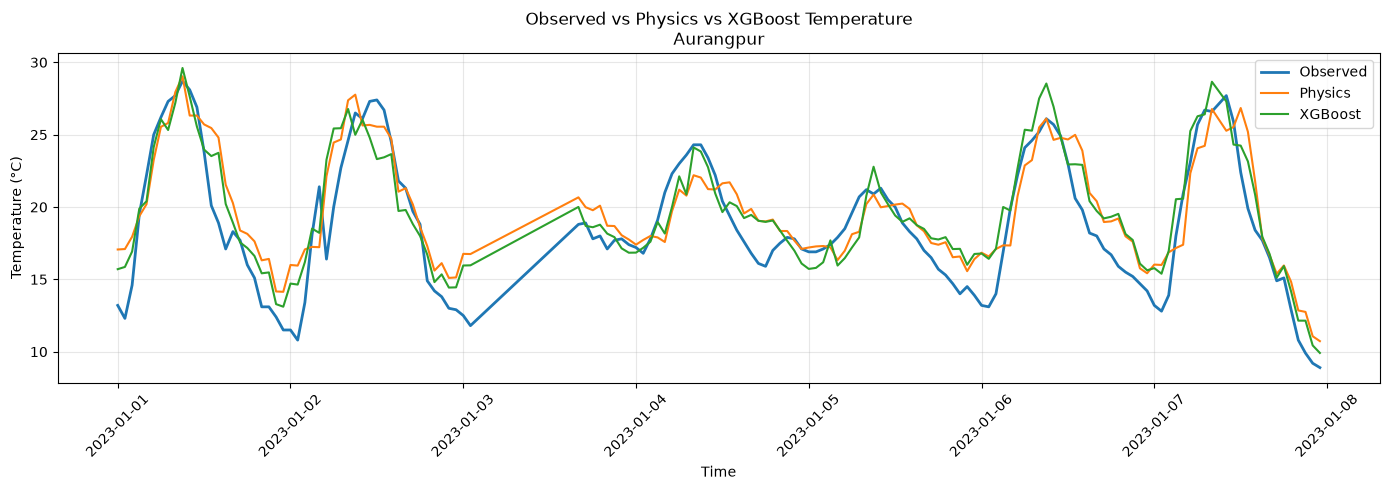

In [50]:
import matplotlib.pyplot as plt

test_station = "Aurangpur"

plot_df = ml_data_qc[
    ml_data_qc["Station"] == test_station
][
    ["time_utc", "observed_temperature_C", "physics_prediction_C"]
].copy()

# XGBoost predicts the residual, so add it back to the physics prediction
plot_df["ml_prediction_C"] = (
    plot_df["physics_prediction_C"].values
    + xgb_predictions[test_station]
)

plot_df = plot_df.sort_values("time_utc")

# First 7 days
start_time = plot_df["time_utc"].min()
end_time = start_time + pd.Timedelta(days=7)

plot_df = plot_df[
    (plot_df["time_utc"] >= start_time) &
    (plot_df["time_utc"] < end_time)
]

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["time_utc"],
    plot_df["observed_temperature_C"],
    label="Observed",
    linewidth=2
)

plt.plot(
    plot_df["time_utc"],
    plot_df["physics_prediction_C"],
    label="Physics",
    linewidth=1.5
)

plt.plot(
    plot_df["time_utc"],
    plot_df["ml_prediction_C"],
    label="XGBoost",
    linewidth=1.5
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Observed vs Physics vs XGBoost Temperature\n{test_station}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

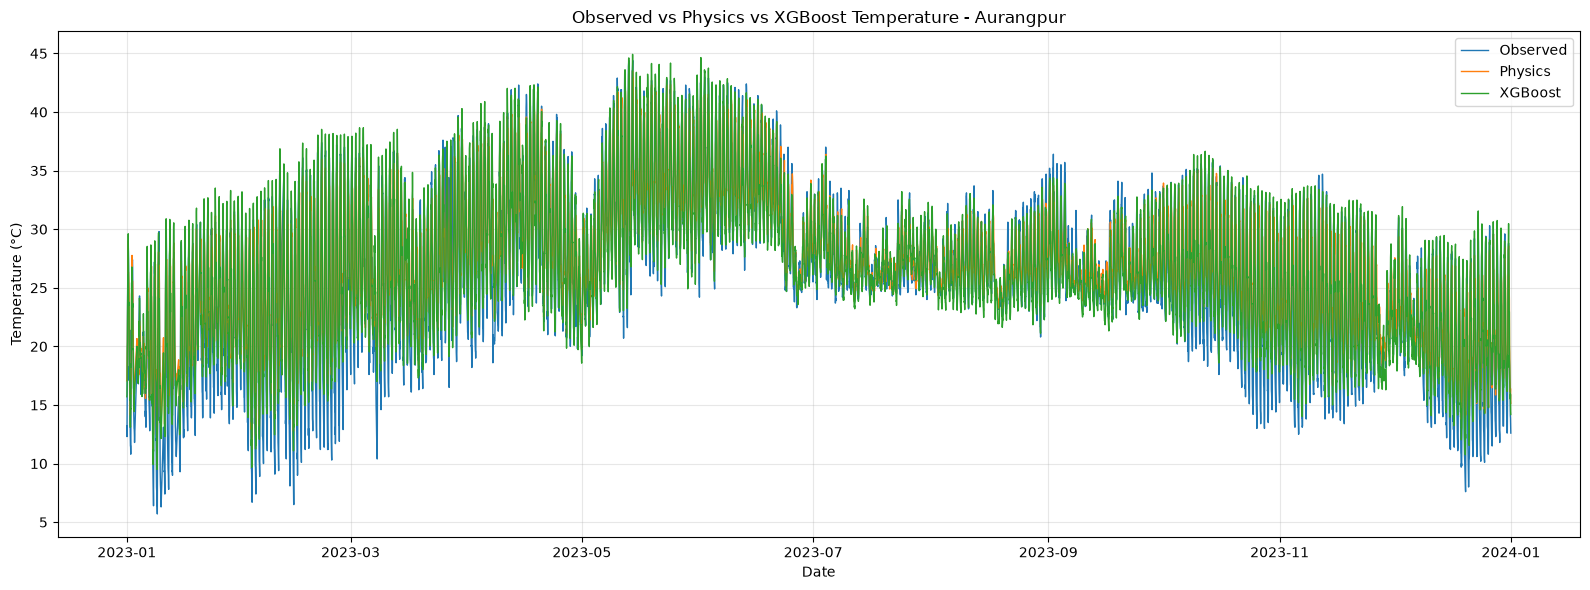

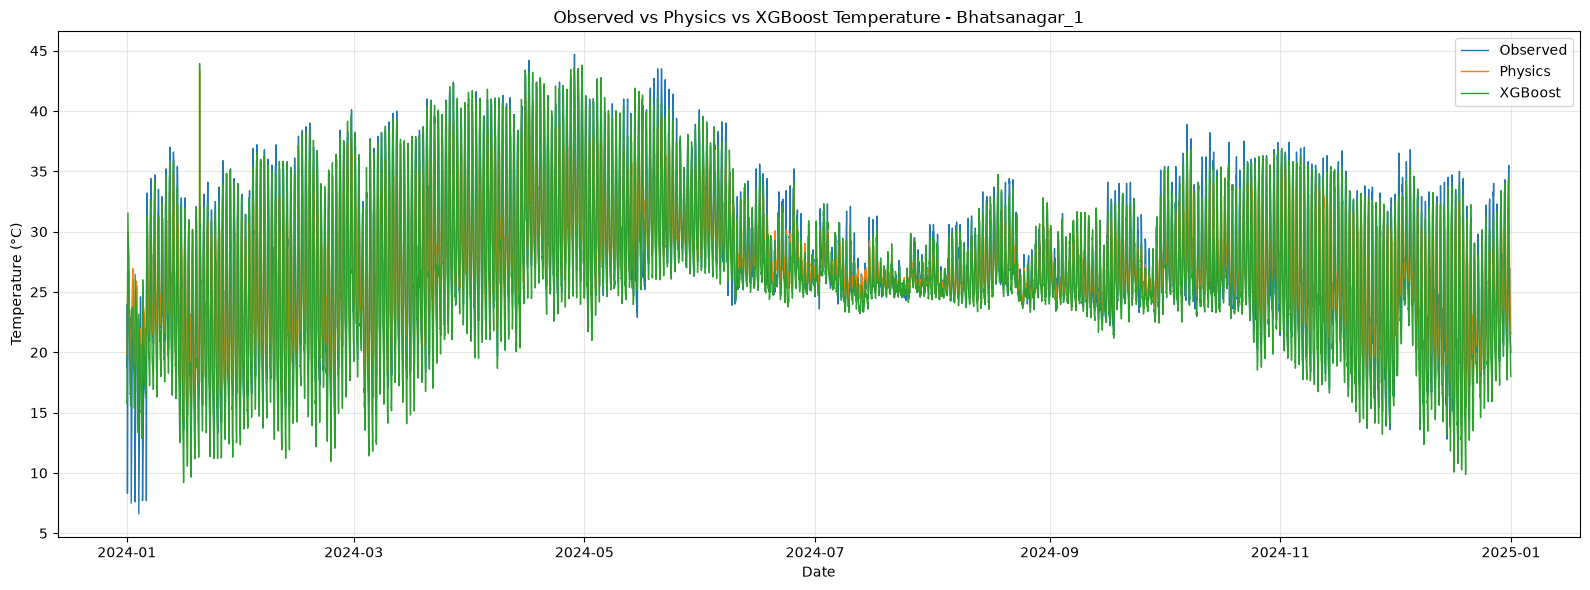

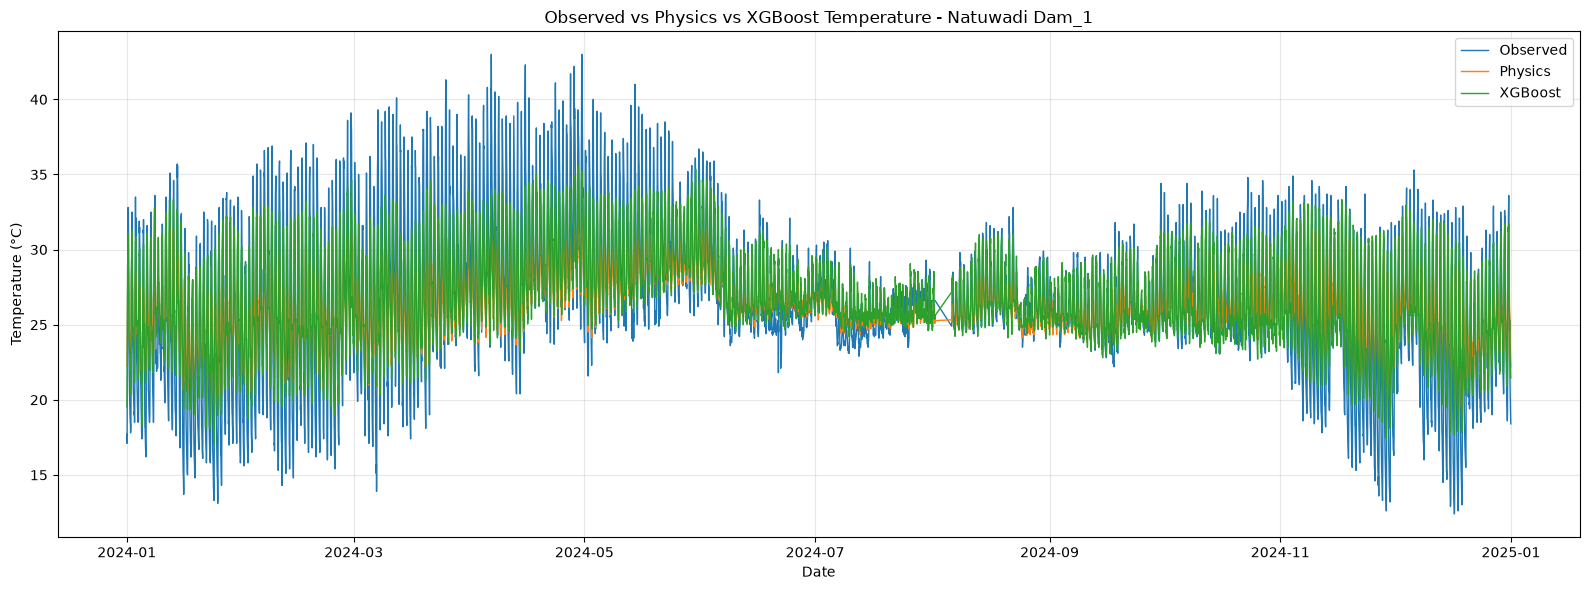

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

stations = ["Aurangpur", "Bhatsanagar_1", "Natuwadi Dam_1"]

# Create a Series to store XGBoost residual predictions
xgb_residual_series = pd.Series(index=X_clean.index, dtype=float)

# Put each station's LOSO predictions back onto the correct rows
for station in stations:
    station_idx = X_clean.index[station_labels == station]
    xgb_residual_series.loc[station_idx] = xgb_predictions[station]

# Build plotting dataframe
plot_all = ml_data_qc[
    ["Station", "time_utc", "observed_temperature_C", "physics_prediction_C"]
].copy()

# Add XGBoost residual
plot_all["xgb_residual_C"] = xgb_residual_series

# Convert residual prediction into final temperature prediction
plot_all["xgb_prediction_C"] = (
    plot_all["physics_prediction_C"] +
    plot_all["xgb_residual_C"]
)

# Plot each station for the full year
for station in stations:

    df = plot_all[
        plot_all["Station"] == station
    ].dropna(subset=["xgb_prediction_C"]).sort_values("time_utc")

    plt.figure(figsize=(16, 6))

    plt.plot(
        df["time_utc"],
        df["observed_temperature_C"],
        label="Observed",
        linewidth=1
    )

    plt.plot(
        df["time_utc"],
        df["physics_prediction_C"],
        label="Physics",
        linewidth=1
    )

    plt.plot(
        df["time_utc"],
        df["xgb_prediction_C"],
        label="XGBoost",
        linewidth=1
    )

    plt.title(f"Observed vs Physics vs XGBoost Temperature - {station}")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()